<a href="https://colab.research.google.com/github/khanzaveriya/task-manager/blob/main/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17477 entries, 0 to 17476
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          17477 non-null  int64  
 1   season            17477 non-null  int64  
 2   phase             17477 non-null  object 
 3   match_no          17477 non-null  int64  
 4   date              17477 non-null  object 
 5   venue             17477 non-null  object 
 6   batting_team      17477 non-null  object 
 7   bowling_team      17477 non-null  object 
 8   innings           17477 non-null  int64  
 9   over              17477 non-null  float64
 10  striker           17477 non-null  object 
 11  bowler            17477 non-null  object 
 12  runs_of_bat       17477 non-null  int64  
 13  extras            17477 non-null  int64  
 14  wide              17477 non-null  int64  
 15  legbyes           17477 non-null  int64  
 16  byes   

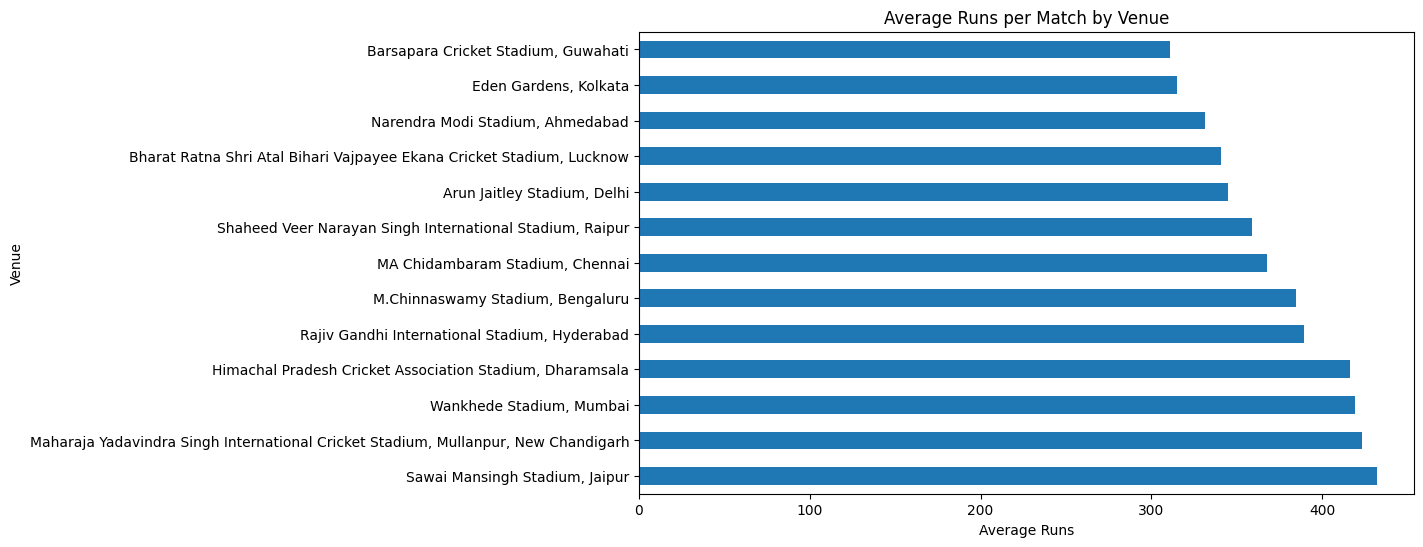

Insight:
Sawai Mansingh Stadium, Jaipur had the highest average runs per match (428.67), making it the highest-scoring venue.


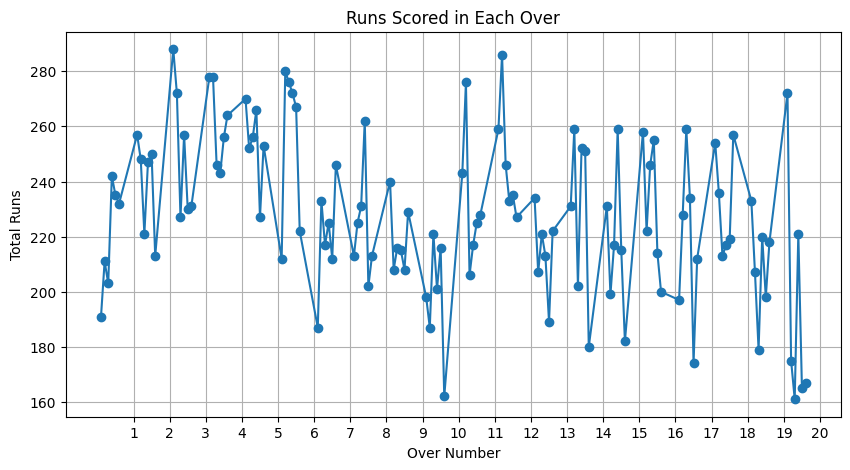

Insight:
The highest runs were scored around the 5th over, showing batters scored more agressively during that phase of the innings.

==============Conclusion==============
The IPL 2026 dataset was successfully analyzed using Python and Pandas. The analysis identified the
 top six-hitting team, leading wicket-taking bowler, busiest venue, most-used bowler, highest-scoring
stadium, and the overs with the most runs. These insights show that data analysis helps understand team
 performance, player contribution, and match trends effectively through real match data.


In [4]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

df = pd.read_csv("ipl_2026_deliveries.csv")

# 3. Data Inspection

print("\n========== DATA INFO ==========")
df.info()

print("\n=========== Shape (Rows, Columns) ============")
print(df.shape)

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe(include='all'))

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n========== Number of Rows ==========")
print(len(df))

print("\n========== Column Names ===========")
print(df.columns.tolist())

# 4. Data Cleaning

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())
print("Insight:")
print("Missing values in wicket-related columns are valid because wickets do not occur on every ball.")

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

# ANALYTICAL QUESTIONS

# Q1. Which team hit the most sixes?

sixes = df[df["runs_of_bat"] == 6]
result = sixes.groupby("batting_team").size().sort_values(ascending=False)
print("\n",result)
print("Insight:")
print("PBKS hit the highest number of sixes (156), showing strong power-hitting throughout the tournament.")

# Q2. Which venue hosted the most deliveries?

venue_deliveries = df['venue'].value_counts()
top_venue = venue_deliveries.idxmax()
total_deliveries = venue_deliveries.max()
print("\nVenue with the most deliveries:", top_venue)
print("Total deliveries:", total_deliveries)
print("Insight:")
print("Arun Jaitley Stadium, Delhi hosted the most deliveries (1569), indicating it was one of the busiest venues.")

# Q3. Which bowler has taken the most wickets?

top_bowler = df[df['player_dismissed'].notna()]['bowler'].value_counts()
print("\nBowler with most wickets:",top_bowler.index[0])
print("Wickets:",top_bowler.iloc[0])
print("Insight:")
print("Bhuvneshwar Kumar took the highest number of wickets (25), making him the most successful wicket-taker.")

# Q4. Which bowler bowled the most deliveries?

most_deli = df.groupby("bowler").size().sort_values(ascending=False)
print("\n",most_deli)
print("Insight:")
print("Arshdeep Singh bowled the most deliveries (323), showing he was consistently used by his team.")

# Q5. Which stadiums have the highest average runs per match?

df["total_runs"] = df["runs_of_bat"] + df["extras"]
match_runs = df.groupby(["match_id", "venue"])["total_runs"].sum().reset_index()
venue_avg_runs = (match_runs.groupby("venue")["total_runs"].mean().sort_values(ascending=False))
print("\n",venue_avg_runs)
plt.figure(figsize=(10,6))
venue_avg_runs.plot(kind="barh")
plt.title("Average Runs per Match by Venue")
plt.xlabel("Average Runs")
plt.ylabel("Venue")
plt.show()
print("Insight:")
print("Sawai Mansingh Stadium, Jaipur had the highest average runs per match (428.67), making it the highest-scoring venue.")

# Q6. Which overs produced the most runs?

df["total_runs"] = df["runs_of_bat"] + df["extras"]
over_runs = df.groupby("over")["total_runs"].sum()
plt.figure(figsize=(10,5))
plt.plot(over_runs.index, over_runs.values, marker='o')
plt.title("Runs Scored in Each Over")
plt.xlabel("Over Number")
plt.ylabel("Total Runs")
plt.xticks(range(1,21))
plt.grid(True)
plt.show()
print("Insight:")
print("The highest runs were scored around the 5th over, showing batters scored more agressively during that phase of the innings.")


print("\n==============Conclusion==============")
print("The IPL 2026 dataset was successfully analyzed using Python and Pandas. The analysis identified the")
print(" top six-hitting team, leading wicket-taking bowler, busiest venue, most-used bowler, highest-scoring")
print("stadium, and the overs with the most runs. These insights show that data analysis helps understand team")
print(" performance, player contribution, and match trends effectively through real match data.")